In [1]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp

import optax
import flax.linen as nn
from flax.training.train_state import TrainState
 
import matplotlib.pyplot as plt

import json
from pathlib import Path
from toolbox import *
import os

print("jax", jax.__version__)
print("jaxlib", jax.lib.__version__)
print("JAX_PLATFORMS =", os.environ.get("JAX_PLATFORMS"))
print("LD_LIBRARY_PATH =", os.environ.get("LD_LIBRARY_PATH"))
print(jax.devices())


jax 0.6.2
jaxlib 0.6.2
JAX_PLATFORMS = None
LD_LIBRARY_PATH = None
[CudaDevice(id=0)]


# jax seed

In [2]:
seed = 1234
key = jax.random.key(seed)

# Load json

In [3]:
def _strip_comment_keys(obj):
    """Recursively drop any keys that start with '//'."""
    if isinstance(obj, dict):
        return {k: _strip_comment_keys(v) for k, v in obj.items()
                if not (isinstance(k, str) and k.startswith("//"))}
    if isinstance(obj, list):
        return [_strip_comment_keys(x) for x in obj]
    return obj

def load_config_dict(config_directory: Path, filename: str = "configuration.json") -> dict:
    path = (config_directory / filename).resolve()
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return _strip_comment_keys(data)

config_directory = Path("")
cfg = load_config_dict(config_directory, "configuration.json")



# Hamiltonian parameters (MHz units)
chi = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
qubit_anham = 2 * jnp.pi * cfg["anharmonicity_MHz"]
K_c = 2*jnp.pi*cfg["self_Kerr_kHz"]*1e-3  # cavity self-Kerr MHz

print("chi (MHz)", chi / (2 * jnp.pi))
print("qubit anham (MHz)", qubit_anham / (2 * jnp.pi))
print("cavity self-Kerr (MHz)", K_c / (2 * jnp.pi))


# Relaxation times (not used in this unitary optimizer, but keep)
t1_qub = cfg["qubit_T1_us"]
t2_qub = cfg["qubit_T2_us"]
t1_cav = cfg["storage_T1_us"]

chi (MHz) -0.6597441199877514
qubit anham (MHz) -164.271
cavity self-Kerr (MHz) -0.0007211


## Problem parameters

#### Static constants (should not be modified during training)

In [4]:

num_bspln = 20    # Desired number of basis pulses
delta_ns = 64 # Grid interval, must be a multiple of 4ns. (proportional to control pulse duration devided by bspline number)


inp_shape = (1,) #should not be modified at all
osz = num_bspln * 4 #should not be modified at all
rec_features = osz
dense_features = [int(osz * 2), int(osz * 3), int(osz * 2)] #can be modified to modify the neural network size (feedback time should be modified accordingly)
print("rec_features:", rec_features)
print("dense_features:" , dense_features)

big_nn = (len(dense_features)==3) #assumes either 3 or 2 hidden layers


rec_features: 80
dense_features: [160, 240, 160]


#### Dynamic constants

In [5]:
ndt_drive = 300 #number of steps during unitary control
dephasing=True# Whether to include readout-induced dephasing in the model. If True, the optimizer will learn to mitigate it.
N_cav = 23 #Hibert space dimension of cavity
t_idle = 15 #in us, average time betwenn readout and next control drive
# psi_target_cav = coherent(N_cav,2.0)-coherent(N_cav,-2.0) #unnormalised target state to stabilize
psi_target_cav = basis(N_cav, 2) #unnormalised target state to stabilize
save_name = "trained_nn12_cat_target_v4_20bspln_fock2"


psi_target_cav /= jnp.sqrt(hconj(psi_target_cav) @ psi_target_cav) #normalization of the state

## Time-grids and B-splines

--- Pulse Properties ---
B-spline Degree (k)     : 2
Grid step (delta_ns)    : 64 ns
Single pulse length     : 192 ns
Total sequence duration : 1408 ns (1.408 us)
Max overlapping pulses  : 3
------------------------


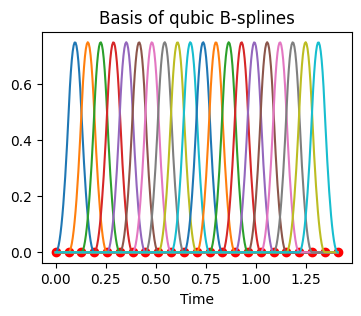

In [6]:
k = 2 #quartic bsplines (only 3 non zero bsplines simultaneously)

# Skip exactly 'k' on both sides to use purely uniform interior splines
skip_left = k
skip_right = k
n = num_bspln + skip_left + skip_right  # Total knots required = 24

m = n - k  # Total uniform intervals = 22

T_ns_hw = m * delta_ns
T_us_hw = T_ns_hw / 1000.0

time_start = 0.0
time_end = T_us_hw

# A degree k B-spline spans exactly k+1 intervals
L_ns = (k + 1) * delta_ns  

t_drive = T_us_hw






print("--- Pulse Properties ---")
print(f"B-spline Degree (k)     : {k}")
print(f"Grid step (delta_ns)    : {delta_ns} ns")
print(f"Single pulse length     : {L_ns} ns")
print(f"Total sequence duration : {T_ns_hw} ns ({T_us_hw} us)")
print(f"Max overlapping pulses  : {k + 1}")
print("------------------------")
assert L_ns % 4 == 0, "Pulse length is not a multiple of 4 ns!"



# build the bspline basis
t_drive_edges = jnp.linspace(0, t_drive, ndt_drive + 1)
t_drive_mids = (t_drive_edges[1:] + t_drive_edges[:-1]) / 2
t_drive_intvs = t_drive_edges[1:] - t_drive_edges[:-1]

bspline_builder = setup_bspline_builder(0, t_drive_edges[-1], n, k, skip_left, skip_right)

bsplns_mids = bspline_builder(t_drive_mids)
bsplns_edges = bspline_builder(t_drive_edges)

knots = bknots_on_interval(0, t_drive_edges[-1], n, k)
knots = np.unique(knots)

# TEST
fig, ax = plt.subplots(figsize=(4, 3))

for i in range(bsplns_edges.shape[0]):
    ax.plot(t_drive_edges, bsplns_edges[i])
        
ax.scatter(knots, np.zeros_like(knots), color="red");   
ax.set_xlabel("Time");
ax.set_title("Basis of qubic B-splines");


## Driven Hamiltonian

In [7]:
mu_qub = 20.0 #make the coeff big enough so that the amps remain betwee -2 and 2 (don't modify the coef unless you modify it in the qua programm too)
mu_cav = 20.0

def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a
    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    H_disp = (chi / 2) * n_phot @ (one - sigz)
    H_kerr = 0.5 * K_c * adag @ adag @ a @ a

    # Combined drift Hamiltonian
    H_drift = H_disp + H_kerr
    
    ht = [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],                
        [mu_cav * adag, 1j *jnp.conj(e_cav), 1, 1] 
    ]
    return ht

def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    hmat = hmat_from_htree(htree)
    return evol_hdt_exp(hmat, dt)

def make_drive(N_cav, chi):
    
    def drive(rho_init, es_qub, es_cav, dts):
        
        def f(rho, x):
            e_qub, e_cav, dt = x
            uevol = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            return uevol @ rho @ hconj(uevol), None
    
        rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])
        return rho_fin
    
    return drive

def ctrl_from_coeffs(ctrl_coeffs, bsplns):
    ctrls_real = ctrl_coeffs @ bsplns
    e_qub = ctrls_real[0, ...] + 1j * ctrls_real[1, ...]
    e_cav = ctrls_real[2, ...] + 1j * ctrls_real[3, ...]
    return e_qub, e_cav

## Relaxation

In [8]:
def qubit_ops():
    g = basis(2)       # |g> = index 0
    e = basis(2, 1)    # |e> = index 1

    Pg = g @ hconj(g)
    Pe = e @ hconj(e)

    sm = g @ hconj(e)  # |g><e|, relaxation operator
    sp = e @ hconj(g)  # |e><g|, excitation operator

    sz = Pg - Pe       # diag(+1, -1)

    return g, e, Pg, Pe, sm, sp, sz

def liouv_relax_channel(c):
    l = tensor(c, c.conj())
    l -= 1 / 2 * tensor(hconj(c) @ c, identity(len(c)))
    l -= 1 / 2 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return l

def eval_idling_matrix(cs, t):
    l = sum(liouv_relax_channel(c) for c in cs)
    return jsp.linalg.expm(l * t)

def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    get_t_phi_qub = lambda t1, t2: 1 / ((1 / t2) - (1 / t1) / 2)
    t_phi_qub = get_t_phi_qub(t1_qub, t2_qub)

    g, e, Pg, Pe, sm, sp, sz = qubit_ops()

    sig_down = tensor(sm, identity(N_cav))
    sigz = tensor(sz, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))
    
    c_ops = [
        1 / jnp.sqrt(t1_qub) * sig_down,
        1 / jnp.sqrt(t_phi_qub) * sigz / jnp.sqrt(2),
        1 / jnp.sqrt(t1_cav) * a,
    ]

    return c_ops

def make_idle(N_cav, t1_qub, t2_qub, t1_cav, t):
    cs = build_c_ops(N_cav, t1_qub, t2_qub, t1_cav)
    idling_matrix = eval_idling_matrix(cs, t)

    def idle(rho):
        rho_liouv = rho.reshape(-1, 1)
        rho_liouv = idling_matrix @ rho_liouv
        return rho_liouv.reshape(rho.shape)

    return idle


print("sigma.m =", sigma.m)

sigma.m = [[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]


## Fidelity of the cavity state

In [9]:
def fidelity_cav(rho, psi_target_cav):
    idx_mid = rho.shape[-1] // 2
    rho_cav = rho[:idx_mid, :idx_mid] + rho[idx_mid:, idx_mid:]
    fid = hconj(psi_target_cav) @ rho_cav @ psi_target_cav
    return jnp.real(fid[0, 0])


def fidelity_cav_only_cav_rho(rho, psi_target_cav):
    fid = hconj(psi_target_cav) @ rho @ psi_target_cav
    return jnp.real(fid[0, 0])

## Effective qubit readout model

At each feedback step, the input state is the full qubit+cavity density matrix $\rho$.  
The qubit readout is modeled as a projective measurement of the qubit, followed by an effective cavity backaction.

---

#### 1. Projective qubit measurement

In the qubit basis $\{|g\rangle, |e\rangle\}$, we write

$$
\rho =
\begin{pmatrix}
\rho_{gg} & \rho_{ge} \\
\rho_{eg} & \rho_{ee}
\end{pmatrix},
$$

where each block acts on the cavity Hilbert space.

The probabilities of measuring the qubit in $|g\rangle$ or $|e\rangle$ are

$$
p_g = \mathrm{Tr}(\rho_{gg}),
\qquad
p_e = \mathrm{Tr}(\rho_{ee}).
$$

After the measurement, the cavity state is projected onto the corresponding block:

$$
\rho_{\mathrm{cav}}^{(g)}
=
\frac{\rho_{gg}}{p_g},
\qquad
\rho_{\mathrm{cav}}^{(e)}
=
\frac{\rho_{ee}}{p_e}.
$$

In the simulation, the measurement outcome is encoded as

$$
m = +1 \quad \text{for } |g\rangle,
\qquad
m = -1 \quad \text{for } |e\rangle.
$$

---

#### 2. Readout-induced cavity rotation

The readout pulse produces an effective rotation of the cavity state in phase space.  
The rotation angles are taken from the experimental calibration:

$$
\theta_g = -18.00^\circ,
\qquad
\theta_e = -165.25^\circ.
$$

These angles use the trigonometric convention: positive angle means counter-clockwise rotation in phase space.

The rotation is implemented as

$$
U(\theta) = e^{+i\theta \hat n},
$$

so that

$$
\rho_{\mathrm{cav}}
\rightarrow
U(\theta)\rho_{\mathrm{cav}}U^\dagger(\theta).
$$

Equivalently, in the Fock basis,

$$
\rho_{mn}
\rightarrow
e^{i\theta(m-n)}\rho_{mn}.
$$

With this convention, the negative readout angles correspond to clockwise phase-space rotations. This is opposite to the free dispersive rotation of the cavity when the qubit is in $|e\rangle$ for our negative-$\chi$ Hamiltonian.

---

#### 3. Average phase noise

We also include an additional random phase uncertainty with standard deviation

$$
\sigma_{\theta,g} = 3.46^\circ \qquad \sigma_{\theta,e} = 9.28^\circ.
$$

This models the fact that the readout-induced cavity rotation is not perfectly deterministic during the readout (due to the randomness of the photon number in the readout).

For a single trajectory, the phase rotation angle is written as

$$
\theta = \theta_{rot} + \delta\theta,
$$

where the random phase error is Gaussian distributed,

$$
\delta\theta \sim \mathcal{N}(0,\sigma_\theta^2).
$$

The corresponding unitary rotation is

$$
U(\theta_{rot} + \delta\theta)
=
e^{+i(\theta_{rot}+\delta\theta)\hat n}.
$$

In the Fock basis, this gives

$$
\rho_{mn}
\rightarrow
e^{i(\theta_{rot}+\delta\theta)(m-n)}
\rho_{mn}.
$$

We can separate the deterministic part from the random part:

$$
\rho_{mn}
\rightarrow
e^{i\theta_{rot}(m-n)}
e^{i\delta\theta(m-n)}
\rho_{mn}.
$$

Instead of sampling a different $\delta\theta$ for every trajectory, we average over the Gaussian distribution exactly. Therefore we need to compute

$$
\left\langle e^{i\delta\theta(m-n)} \right\rangle_{\delta\theta}.
$$

Using the Gaussian probability density,

$$
P(\delta\theta)
=
\frac{1}{\sqrt{2\pi}\sigma_\theta}
\exp\left(
-\frac{\delta\theta^2}{2\sigma_\theta^2}
\right),
$$

we get

$$
\left\langle e^{i\delta\theta(m-n)} \right\rangle_{\delta\theta}
=
\int_{-\infty}^{+\infty}
\frac{d\delta\theta}{\sqrt{2\pi}\sigma_\theta}
\exp\left(
-\frac{\delta\theta^2}{2\sigma_\theta^2}
\right)
\exp\left(
i\delta\theta(m-n)
\right) = e^{-\frac{1}{2}\sigma_\theta^2(m-n)^2}.
$$


Therefore, the averaged excited-outcome readout backaction is

$$
\rho_{mn}
\rightarrow
e^{i\theta_e(m-n)}
e^{-\frac{1}{2}\sigma_{\theta,e}^2(m-n)^2}
\rho_{mn}.
$$

similarly the averaged ground-outcome readout backaction is

$$
\rho_{mn}
\rightarrow
e^{i\theta_g(m-n)}
e^{-\frac{1}{2}\sigma_{\theta,g}^2(m-n)^2}
\rho_{mn}.
$$

The important point is that the phase noise does not change the diagonal elements $\rho_{nn}$, because then $m-n=0$.  
It only suppresses off-diagonal coherences in the Fock basis, with stronger suppression for matrix elements farther away from the diagonal.

---

#### 4. Qubit reset

After the readout, the qubit is assumed to be reset to $|g\rangle$.  
The final joint state is therefore

$$
\rho_{\mathrm{fin}}
=
|g\rangle\langle g|
\otimes
\rho_{\mathrm{cav}}^{(\mathrm{after\ readout})}.
$$

In [10]:


def measure_sz(
    key,
    rho_init,
    psi_target_cav,
    theta_g_deg=-18.00,
    theta_e_deg=-165.50,
    sigma_theta_g_deg=3.46,
    sigma_theta_e_deg=9.29,
    
):
    eps = 1e-12
    N_cav = rho_init.shape[0] // 2

    # ------------------------------------------------------------
    # 1. Projective qubit measurement
    # ------------------------------------------------------------
    # In the {|g>, |e>} basis, write
    #
    #     rho = [[rho_gg, rho_ge],
    #            [rho_eg, rho_ee]]
    #
    # The measurement probabilities are
    #
    #     p_g = Tr(rho_gg)
    #     p_e = Tr(rho_ee)
    rho_gg = rho_init[:N_cav, :N_cav]
    rho_ee = rho_init[N_cav:, N_cav:]

    p_g = jnp.real(jnp.trace(rho_gg))
    p_e = jnp.real(jnp.trace(rho_ee))

    # Numerical safeguard:
    # p_g and p_e should be positive and sum to one, but tiny numerical
    # errors can produce slightly negative values or a sum slightly different
    # from one. We clip and renormalize only for sampling.
    p_sample = jnp.array([p_g, p_e])
    p_sample = jnp.maximum(p_sample, eps)
    probs = p_sample / jnp.sum(p_sample)

    # outcome_index = 0 -> measured |g>
    # outcome_index = 1 -> measured |e>
    outcome_index = jax.random.choice(key, 2, p=probs)
    outcome_is_g = outcome_index == 0

    # Probability of the sampled outcome, used for trajectory weighting.
    prob = probs[outcome_index]

    # Select the cavity block corresponding to the measurement outcome.
    rho_cav = jnp.where(
        outcome_is_g,
        rho_gg,
        rho_ee,
    )

    # Normalize the selected cavity state:
    #
    #     rho_cav^(g) = rho_gg / p_g
    #     rho_cav^(e) = rho_ee / p_e
    #
    # We normalize using the actual trace of the selected block.
    # eps only protects against division by zero in pathological cases.
    norm = jnp.real(jnp.trace(rho_cav))
    norm = jnp.maximum(norm, eps)
    rho_cav = rho_cav / norm


    # Fidelity before the full readout backaction.
    fid_meas = fidelity_cav_only_cav_rho(rho_cav, psi_target_cav)

    # ------------------------------------------------------------
    # 2. Readout-induced cavity rotation
    # ------------------------------------------------------------
    # The calibrated readout rotation depends on the measured qubit state:
    #
    #     theta_rot = theta_g  for outcome |g>
    #     theta_rot = theta_e  for outcome |e>
    theta_rot_deg = jnp.where(
        outcome_is_g,
        theta_g_deg,
        theta_e_deg,
    )
    theta_rot_rad = theta_rot_deg * jnp.pi / 180.0

    # Fock-basis index difference m - n.
    n = jnp.arange(N_cav)
    mn_diff = n[:, None] - n[None, :]

    # Implements
    #
    #     rho_mn -> exp(i theta_rot (m-n)) rho_mn
    #
    # corresponding to
    #
    #     U(theta_rot) = exp(+i theta_rot n_hat).
    rotation_matrix = jnp.exp(1j * theta_rot_rad * mn_diff)
    rho_cav = rotation_matrix * rho_cav
    if dephasing:
        # ------------------------------------------------------------
        # 3. Averaged Gaussian phase noise
        # ------------------------------------------------------------
        # For both outcomes, we model an additional random phase error:
        #
        #     theta = theta_rot + delta_theta
        #
        # with
        #
        #     delta_theta ~ Normal(0, sigma_theta^2).
        #
        # Instead of sampling delta_theta, we average exactly:
        #
        #     <exp(i delta_theta (m-n))>
        #       = exp[-0.5 sigma_theta^2 (m-n)^2].
        sigma_theta_deg = jnp.where(
            outcome_is_g,
            sigma_theta_g_deg,
            sigma_theta_e_deg,
        )
        sigma_theta_rad = sigma_theta_deg * jnp.pi / 180.0

        dephasing_matrix = jnp.exp(
            -0.5 * sigma_theta_rad**2 * mn_diff**2
        )

        rho_cav = dephasing_matrix * rho_cav

        # # Numerical safeguard:
        # # the exact readout map preserves Hermiticity, but tiny anti-Hermitian
        # # components can appear from floating-point arithmetic.
        # rho_cav = 0.5 * (rho_cav + jnp.conj(rho_cav.T))

    # ------------------------------------------------------------
    # 4. Qubit reset to |g>
    # ------------------------------------------------------------
    # After readout, the qubit is assumed to be reset to |g>, so the final
    # joint state has only the |g><g| cavity block populated:
    #
    #     rho_fin = |g><g| tensor rho_cav
    rho_fin = jnp.zeros_like(rho_init)
    rho_fin = rho_fin.at[:N_cav, :N_cav].set(rho_cav)

    # Measurement encoding:
    #
    #     +1 for |g>
    #     -1 for |e>
    meas_out = jnp.where(outcome_is_g, 1, -1)

    return rho_fin, meas_out, prob, fid_meas


## RNN

In [11]:
def init_carry(key, rec_features, inp_shape):
    gru_cell = nn.GRUCell(features=rec_features)
    return gru_cell.initialize_carry(key, inp_shape)

def create_flax_state(key,
                      rec_features, dense_features,
                      inp_shape, learning_rate,
                      *, print_summary):
    
    class Model(nn.Module):
    
        @nn.compact
        def __call__(self, carry, x):
            
            gru_cell = nn.GRUCell(features=rec_features)
            carry, x = gru_cell(carry, x)
            
            for ndf in dense_features:
                x = nn.Dense(ndf)(x)
                x = jax.nn.relu(x)
                
            out_layer = nn.Dense(4 * num_bspln)
            x = out_layer(x)
            x = x.reshape(4, num_bspln)
            
            return carry, x

    model = Model()

    fake_key = jax.random.key(0)
    fake_carry = init_carry(fake_key, rec_features, inp_shape)
    fake_inp = jnp.ones(inp_shape)
    params = model.init(key, fake_carry, fake_inp)["params"]

    # optimizer = optax.adam(learning_rate=learning_rate)
    optimizer = optax.chain( #avoid unlikely trajectory to create catastrophic update
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=1e-5),
    )

    flax_state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    if print_summary:
        print(model.tabulate(fake_key, fake_carry, fake_inp))

    return flax_state

def apply_nn(flax_state, params, carry, inp):
    return flax_state.apply_fn({'params': params}, carry, inp)


key, subkey = jax.random.split(key)
flax_state = create_flax_state(
    subkey, rec_features, dense_features, inp_shape, 1e-5,
    print_summary=True
)

mean_fids_train = []



                                 Model Summary                                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module  ┃ inputs        ┃ outputs         ┃ params            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│              │ Model   │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[4,20] │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0    │ GRUCell │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[80]   │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0/ir │ Dense   │ float32[1]    │ float32[80]     │ bias: float32[80] │
│              │         │               │                 │ kernel:           │
│              │         │ 

## Time step  

In [12]:
def make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    idle = make_idle(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
    drive = make_drive(N_cav, chi)
    
    def time_step(key, rho, flax_state, params, carry):
        rho, meas_out, prob, fid_meas = measure_sz(key, rho,psi_target_cav)
        rho = idle(rho)
        rnn_inp = jnp.array([meas_out], dtype=float)
        carry, ctrl_coeffs = apply_nn(flax_state, params, carry, rnn_inp)
        es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
        rho = drive(rho, es_qub, es_cav, t_drive_intvs)  
        fid_after_control = fidelity_cav(rho, psi_target_cav)
        return rho, carry, fid_after_control,fid_meas, meas_out, prob
    
    return time_step

## Trajectory

In [13]:
def make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    time_step = make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory(key, flax_state, params, num_time_steps):
        
        def f(scan_carry, _):
            key, rho, carry = scan_carry
            key, subkey = jax.random.split(key)
            rho, carry, fid,fid_meas, meas_out, prob = time_step(subkey, rho, flax_state, params, carry)
            y = fid,fid_meas, meas_out, prob
            scan_carry = key, rho, carry
            return scan_carry, y
        
        key1, key2 = jax.random.split(key)
        carry = init_carry(key1, rec_features, inp_shape)
        psi_init = tensor(basis(2), psi_target_cav)
        scan_carry = key2, psi_init @ hconj(psi_init), carry
        _, ys = jax.lax.scan(f, scan_carry, length=num_time_steps)
        return ys
    
    return trajectory

## Trajectory with reward gradients

In [14]:
def make_trajectory_with_rewgrad(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    
    trajectory = make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory_with_rewgrad(key, flax_state, num_time_steps):
    
        def func(params):
            traj_out = trajectory(key, flax_state, params, num_time_steps)
            fid_ctrl,fid_meas, meas_out, prob = traj_out
            # rew = -jnp.log(1 - fid.mean())
            # log_prob = jnp.log(prob).sum()
            # return rew + jax.lax.stop_gradient(rew) * log_prob, traj_out
    
            eps = 1e-8
            # fid = 0.5*fid_ctrl+0.5*fid_meas
            fid = fid_meas

            fid_mean = jnp.real(fid.mean())
            fid_mean = jnp.clip(fid_mean, 0.0, 1.0 - eps)

            rew = -jnp.log(1.0 - fid_mean)

            prob_safe = jnp.clip(prob, eps, 1.0)
            log_prob = jnp.log(prob_safe).sum()

            return rew + jax.lax.stop_gradient(rew) * log_prob, traj_out


        grad_func = jax.grad(func, has_aux=True)
        rewgrad, traj_out = grad_func(flax_state.params)
        return rewgrad, traj_out
    
    return trajectory_with_rewgrad

## Train on batch

In [15]:
def make_train_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory_with_rewgrad = make_trajectory_with_rewgrad(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_with_rewgrad_vec = jax.vmap(
            trajectory_with_rewgrad, in_axes=(0, None, None)
        )
    
    @jax.jit
    def train_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        rewgrad, traj_out = trajectory_with_rewgrad_vec(keys, flax_state, num_time_steps)
        lossgrad = jax.tree.map(lambda x: -x.mean(axis=0), rewgrad)
        flax_state = flax_state.apply_gradients(grads=lossgrad) 
        return flax_state, traj_out
    
    return train_on_batch

## Test on batch

In [16]:
def make_test_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory = make_trajectory(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_vec = jax.vmap(
            trajectory, in_axes=(0, None, None, None)
        )
    
    @jax.jit
    def test_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        traj_out = trajectory_vec(keys, flax_state, flax_state.params, num_time_steps)
        return traj_out
    
    return test_on_batch

## >>> Run

In [31]:
num_time_steps_train = 16
num_time_steps_test = 150
batch_size = 32

train_on_batch = make_train_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_train)

test_on_batch = make_test_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_test)

In [ ]:
init_lr = 0.000120
final_lr= 0.000020

constant_steps = 1000
decay_steps = 8000
total_steps = constant_steps + decay_steps

lr_schedule = optax.join_schedules(
    schedules=[
        optax.constant_schedule(init_lr),
        optax.linear_schedule(
            init_value=init_lr,
            end_value=final_lr,
            transition_steps=decay_steps,
        ),
        optax.constant_schedule(final_lr),
    ],
    boundaries=[
        constant_steps,
        constant_steps + decay_steps,
    ],
)

my_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=lr_schedule),
)



flax_state = flax_state.replace(
    tx=my_optimizer,
    opt_state=my_optimizer.init(flax_state.params),
)



In [ ]:
for i in range(constant_steps + decay_steps):
    key, subkey = jax.random.split(key)
    flax_state, traj_out = train_on_batch(subkey, flax_state)
    fids, fid_meas,meas_outs, probs = traj_out
    mean_fid = fids.mean()
    mean_fids_train.append(mean_fid)

    print("i =",i,"    fid_ctrl =",mean_fid, "fid_meas = ",fid_meas.mean())

i = 0     fid_ctrl = 0.62083787 fid_meas =  0.650599
i = 1     fid_ctrl = 0.5674621 fid_meas =  0.60500574
i = 2     fid_ctrl = 0.5857496 fid_meas =  0.6122914
i = 3     fid_ctrl = 0.5157335 fid_meas =  0.5418788
i = 4     fid_ctrl = 0.53749925 fid_meas =  0.5673597
i = 5     fid_ctrl = 0.5442312 fid_meas =  0.5715827
i = 6     fid_ctrl = 0.5818689 fid_meas =  0.6122554
i = 7     fid_ctrl = 0.58310425 fid_meas =  0.607522
i = 8     fid_ctrl = 0.6377771 fid_meas =  0.6612643
i = 9     fid_ctrl = 0.6949049 fid_meas =  0.7246352
i = 10     fid_ctrl = 0.6286734 fid_meas =  0.6596952
i = 11     fid_ctrl = 0.5766988 fid_meas =  0.6041177
i = 12     fid_ctrl = 0.6038209 fid_meas =  0.63155246
i = 13     fid_ctrl = 0.64545226 fid_meas =  0.6730841
i = 14     fid_ctrl = 0.6530287 fid_meas =  0.67674655
i = 15     fid_ctrl = 0.6467267 fid_meas =  0.6761445
i = 16     fid_ctrl = 0.6375145 fid_meas =  0.66027695
i = 17     fid_ctrl = 0.63255525 fid_meas =  0.6554533
i = 18     fid_ctrl = 0.681725 

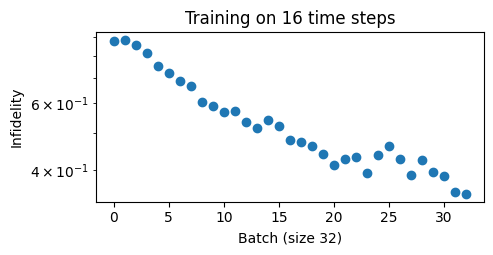

In [20]:
fig, ax = plt.subplots(figsize=(5, 2.2))

ff = jnp.array(mean_fids_train)

ax.scatter(jnp.arange(len(mean_fids_train)), 1 - ff);
ax.set_xlabel(f"Batch (size {batch_size})");
ax.set_ylabel("Infidelity");
ax.set_title(f"Training on {num_time_steps_train} time steps");
ax.set_yscale("log");

#fig.savefig("train.pdf", bbox_inches="tight");

In [21]:

save_flax_state(save_name, flax_state)


In [22]:
#save it in c++ compatible format in the save folder
import struct




def save_cpp_weights(fld, state):
    abs_path = os.path.abspath(fld)
    out_file = os.path.join(abs_path, "weights.bin")

    p = state.params

    if big_nn:
        arrays = [
            np.asarray(p["GRUCell_0"]["ir"]["kernel"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["ir"]["bias"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["hr"]["kernel"], dtype=np.float32),

            np.asarray(p["GRUCell_0"]["iz"]["kernel"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["iz"]["bias"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["hz"]["kernel"], dtype=np.float32),

            np.asarray(p["GRUCell_0"]["in"]["kernel"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["in"]["bias"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["hn"]["kernel"], dtype=np.float32),

            np.asarray(p["Dense_0"]["kernel"], dtype=np.float32),
            np.asarray(p["Dense_0"]["bias"], dtype=np.float32),

            np.asarray(p["Dense_1"]["kernel"], dtype=np.float32),
            np.asarray(p["Dense_1"]["bias"], dtype=np.float32),

            np.asarray(p["Dense_2"]["kernel"], dtype=np.float32),
            np.asarray(p["Dense_2"]["bias"], dtype=np.float32),

            np.asarray(p["Dense_3"]["kernel"], dtype=np.float32),
            np.asarray(p["Dense_3"]["bias"], dtype=np.float32),
        ]
    else:
        arrays = [
            # GRU reset gate
            np.asarray(p["GRUCell_0"]["ir"]["kernel"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["ir"]["bias"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["hr"]["kernel"], dtype=np.float32),

            # GRU update gate
            np.asarray(p["GRUCell_0"]["iz"]["kernel"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["iz"]["bias"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["hz"]["kernel"], dtype=np.float32),

            # GRU candidate gate
            np.asarray(p["GRUCell_0"]["in"]["kernel"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["in"]["bias"], dtype=np.float32),
            np.asarray(p["GRUCell_0"]["hn"]["kernel"], dtype=np.float32),

            # MLP: 80 -> 160
            np.asarray(p["Dense_0"]["kernel"], dtype=np.float32),
            np.asarray(p["Dense_0"]["bias"], dtype=np.float32),

            # MLP: 160 -> 160
            np.asarray(p["Dense_1"]["kernel"], dtype=np.float32),
            np.asarray(p["Dense_1"]["bias"], dtype=np.float32),

            # MLP: 160 -> 80
            np.asarray(p["Dense_2"]["kernel"], dtype=np.float32),
            np.asarray(p["Dense_2"]["bias"], dtype=np.float32),
        ]

    with open(out_file, "wb") as f:
        f.write(b"GRUCPP01")
        f.write(struct.pack("i", len(arrays)))

        for a in arrays:
            a = np.ascontiguousarray(a)
            f.write(struct.pack("i", a.ndim))
            for s in a.shape:
                f.write(struct.pack("i", s))
            f.write(a.tobytes())

    print(f"Saved C++ weights to {out_file}")

save_cpp_weights(save_name, flax_state)

Saved C++ weights to /home/user/python_experiments/train_feedback_grape/trained_nn12_cat_target_v4_20bspln_fock2/weights.bin


# load pretrained RNN

In [ ]:

load_trained = True

if load_trained:
    # === Resume cell 1/2: load an already trained network ===
    #
    # Run the notebook cells above this one first, so that:
    #   - create_flax_state(...) has defined the model architecture,
    #   - flax_state exists as a template TrainState,
    #   - make_train_on_batch(...) is defined.
    #
    # This restores the parameters and optimizer state from an Orbax checkpoint
    # saved by save_flax_state(save_name, flax_state).

    from pathlib import Path
    import orbax.checkpoint as ocp

    resume_save_name = save_name
    resume_step = 1

    def load_flax_state_from_orbax(fld, state_template, *, step=1):
        ckpt_path = Path(fld).resolve() / str(step)
        if not ckpt_path.exists():
            raise FileNotFoundError(f"Checkpoint directory not found: {ckpt_path}")

        ckptr = ocp.Checkpointer(ocp.StandardCheckpointHandler())
        restored_state = ckptr.restore(
            ckpt_path,
            args=ocp.args.StandardRestore(state_template),
        )
        return restored_state

    flax_state = load_flax_state_from_orbax(
        resume_save_name,
        flax_state,
        step=resume_step,
    )

    print(f"Loaded checkpoint from: {Path(resume_save_name).resolve() / str(resume_step)}")
    print("Current TrainState step:", int(flax_state.step))

Loaded checkpoint from: /home/user/python_experiments/train_feedback_grape/trained_nn10_cat_target_v1/1
Current TrainState step: 1585


# plot trajectories

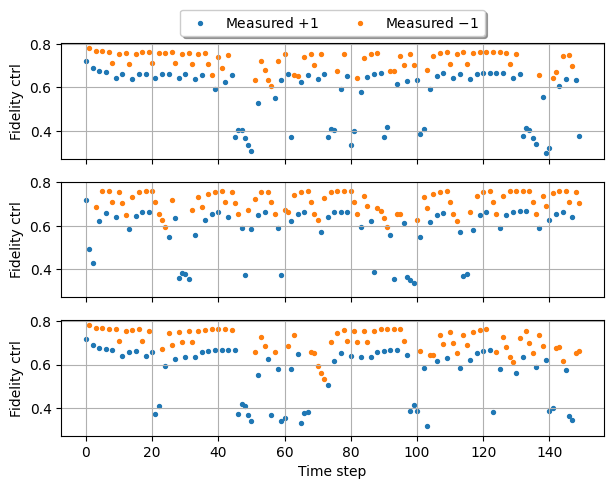

In [ ]:
key, subkey = jax.random.split(key)
traj_out = test_on_batch(subkey, flax_state)
fids, fid_meas, meas_outs, probs = traj_out

test_indx = [0, 1, 2]

fig, axes = plt.subplots(len(test_indx), 1, figsize=(7, 1.7 * len(test_indx)), sharex=True, sharey=True)

for ax, ti in zip(axes, test_indx):
    f = fids[ti]
    m = meas_outs[ti]
    arng = jnp.arange(len(f))
    ax.scatter(arng[m==1], f[m==1], s=8,label=r"Measured $+1$");
    ax.scatter(arng[m==-1], f[m==-1], s=8,label=r"Measured $-1$");
    ax.set_ylabel("Fidelity ctrl");
    ax.grid()
    
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35),
          fancybox=True, shadow=True, ncol=5);
ax.set_xlabel("Time step");
ax.set_title("");

#fig.savefig("stabilize.pdf", bbox_inches="tight");

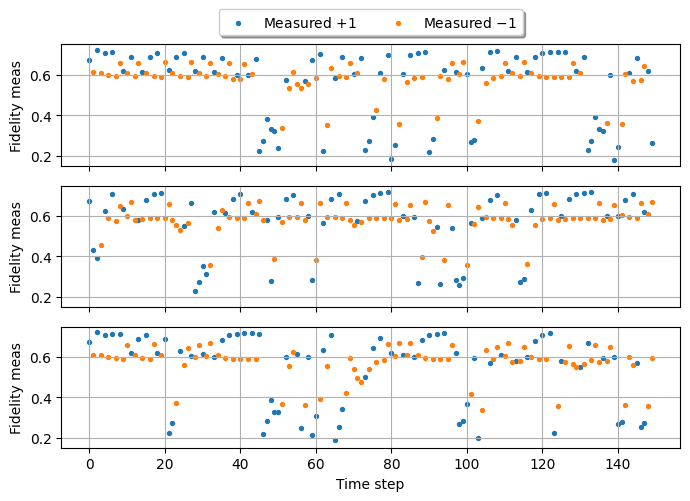

In [ ]:
test_indx = [0, 1, 2]

fig, axes = plt.subplots(len(test_indx), 1, figsize=(7, 1.7 * len(test_indx)), sharex=True, sharey=True)

for ax, ti in zip(axes, test_indx):
    f = fid_meas[ti]
    m = meas_outs[ti]
    arng = jnp.arange(len(f))
    ax.scatter(arng[m==1], f[m==1], s=8,label=r"Measured $+1$");
    ax.scatter(arng[m==-1], f[m==-1], s=8,label=r"Measured $-1$");
    ax.set_ylabel("Fidelity meas");
    ax.grid()
    
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35),
          fancybox=True, shadow=True, ncol=5);
ax.set_xlabel("Time step");
ax.set_title("");
plt.tight_layout()


#fig.savefig("stabilize.pdf", bbox_inches="tight");

# Normal GRAPE optimization with same Hamiltonian and target state

In [ ]:
from tqdm.auto import tqdm
from datetime import datetime
import os
from pathlib import Path

# Normal GRAPE: prepare |g,0> -> |g> tensor psi_target_cav
# Uses the already-defined feedback-GRAPE Hamiltonian through build_drive_htree.

psi_init_grape = tensor(basis(2), basis(N_cav, 0))       # |g,0>
psi_target_grape = tensor(basis(2), psi_target_cav)      # |g> ⊗ target cavity state

grape_optimizer = optax.adam(learning_rate=2e-3)


def grape_fidelity(psi, psi_target):
    overlap = hconj(psi_target) @ psi
    return jnp.abs(overlap[0, 0]) ** 2


def apply_grape_ctrl(grape_ctrl_coeffs):
    e_qub, e_cav = ctrl_from_coeffs(grape_ctrl_coeffs, bsplns_mids)

    # Uses the exact same drift + control Hamiltonians as feedback-GRAPE.
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)

    psi_t = sesolve_htree(htree, psi_init_grape, t_drive_intvs)
    return psi_t


@jax.jit
def grape_train_step(grape_ctrl_coeffs, grape_opt_state):
    def loss_fn(c):
        psi_t = apply_grape_ctrl(c)
        fid = grape_fidelity(psi_t[-1], psi_target_grape)
        return 1.0 - fid, fid

    (loss_val, fid_val), grads = jax.value_and_grad(loss_fn, has_aux=True)(grape_ctrl_coeffs)
    updates, grape_opt_state = grape_optimizer.update(grads, grape_opt_state)
    grape_ctrl_coeffs = optax.apply_updates(grape_ctrl_coeffs, updates)

    return grape_ctrl_coeffs, grape_opt_state, loss_val, fid_val

/home/user/dgx-suite/applications/server/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1000/1000 [00:09<00:00, 107.05it/s, fid=0.991227]


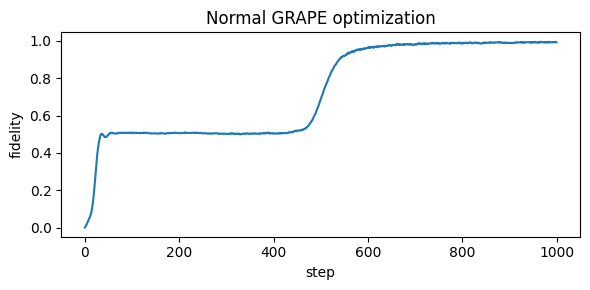

Final normal-GRAPE fidelity: 0.9912270307540894
grape_ctrl_coeffs shape: (4, 20)


In [ ]:
key, subkey = jax.random.split(key)

# Same coefficient shape as the RNN output: [qubit I, qubit Q, cavity I, cavity Q]
grape_ctrl_coeffs = 0.01 * jax.random.normal(subkey, (4, num_bspln))

grape_opt_state = grape_optimizer.init(grape_ctrl_coeffs)

grape_fid_hist = []

n_steps = 1000

pbar = tqdm(range(n_steps))
for i in pbar:
    grape_ctrl_coeffs, grape_opt_state, grape_loss_val, grape_fid_val = grape_train_step(
        grape_ctrl_coeffs, grape_opt_state
    )
    grape_fid_hist.append(float(grape_fid_val))
    pbar.set_postfix(fid=f"{float(grape_fid_val):.6f}")

plt.figure(figsize=(6, 3))
plt.plot(grape_fid_hist)
plt.xlabel("step")
plt.ylabel("fidelity")
plt.title("Normal GRAPE optimization")
plt.tight_layout()
plt.show()

grape_ctrl_coeffs_np = np.asarray(grape_ctrl_coeffs, dtype=float)

print("Final normal-GRAPE fidelity:", grape_fid_hist[-1])
print("grape_ctrl_coeffs shape:", grape_ctrl_coeffs_np.shape)

100%|██████████| 2000/2000 [00:14<00:00, 141.98it/s, fid=1.000063]


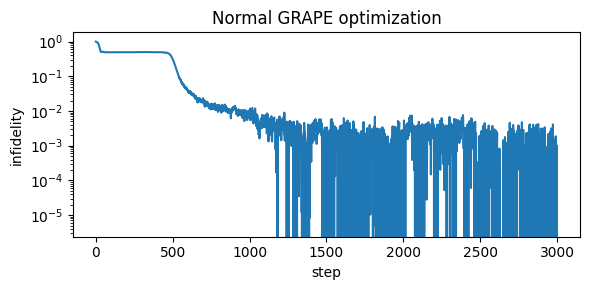

Final normal-GRAPE fidelity: 1.000063180923462
grape_ctrl_coeffs shape: (4, 20)


In [ ]:
grape_optimizer = optax.adam(learning_rate=1e-7)
grape_opt_state = grape_optimizer.init(grape_ctrl_coeffs)

n_steps = 2000

pbar = tqdm(range(n_steps))
for i in pbar:
    grape_ctrl_coeffs, grape_opt_state, grape_loss_val, grape_fid_val = grape_train_step(
        grape_ctrl_coeffs, grape_opt_state
    )
    grape_fid_hist.append(float(grape_fid_val))
    pbar.set_postfix(fid=f"{float(grape_fid_val):.6f}")

plt.figure(figsize=(6, 3))
plt.semilogy(1 - np.asarray(grape_fid_hist))
plt.xlabel("step")
plt.ylabel("infidelity")
plt.title("Normal GRAPE optimization")
plt.tight_layout()
plt.show()

grape_ctrl_coeffs_np = np.asarray(grape_ctrl_coeffs, dtype=float)

print("Final normal-GRAPE fidelity:", grape_fid_hist[-1])
print("grape_ctrl_coeffs shape:", grape_ctrl_coeffs_np.shape)

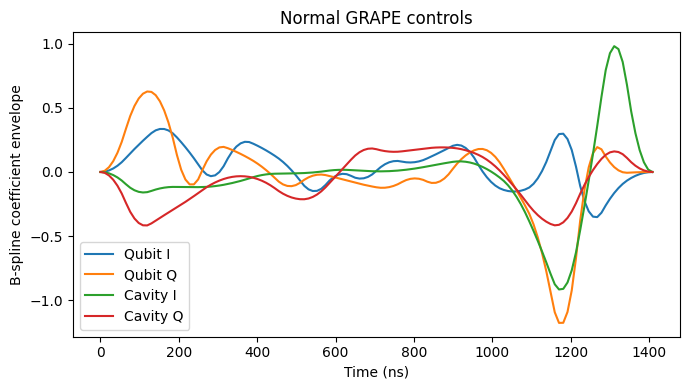

Max raw qubit envelope: 1.177887224984186
Max raw cavity envelope: 0.9821787178183996
Max physical qubit envelope after mu_qub: 23.55774449968372
Max physical cavity envelope after mu_cav: 19.643574356367992


In [ ]:
grape_fields_edges = grape_ctrl_coeffs_np @ np.asarray(bsplns_edges, dtype=float)

plt.figure(figsize=(7, 4))
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[0], label="Qubit I")
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[1], label="Qubit Q")
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[2], label="Cavity I")
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[3], label="Cavity Q")
plt.xlabel("Time (ns)")
plt.ylabel("B-spline coefficient envelope")
plt.title("Normal GRAPE controls")
plt.legend()
plt.tight_layout()
plt.show()

print("Max raw qubit envelope:", np.max(np.abs(grape_fields_edges[:2])))
print("Max raw cavity envelope:", np.max(np.abs(grape_fields_edges[2:])))
print("Max physical qubit envelope after mu_qub:", mu_qub * np.max(np.abs(grape_fields_edges[:2])))
print("Max physical cavity envelope after mu_cav:", mu_cav * np.max(np.abs(grape_fields_edges[2:])))

In [ ]:
# Build OPX-compatible single B-spline basis sampled at 1 ns

t_ns = np.arange(0, T_ns_hw, 1)
t_us = t_ns / 1000.0

B_1ns = np.asarray(bspline_builder(t_us), dtype=float)
assert B_1ns.shape == (num_bspln, T_ns_hw)

eps = 1e-15
nz0 = np.where(np.abs(B_1ns[0]) > eps)[0]
s0_raw = int(nz0[0]) if len(nz0) else 0

s0_grid = int(np.round(s0_raw / delta_ns) * delta_ns)
s0_grid = (s0_grid // 4) * 4

assert 0 <= s0_grid
assert s0_grid + L_ns <= T_ns_hw

basis_single = B_1ns[0, s0_grid:s0_grid + L_ns].copy()
basis_single[0] = 0.0

max_err = 0.0
for i in range(num_bspln):
    si = s0_grid + i * delta_ns
    seg = B_1ns[i, si:si + L_ns]
    err = np.max(np.abs(seg - basis_single))
    max_err = max(max_err, err)

print("Max shift-match error:", max_err)
assert max_err < 1e-6

# Reconstruct full 1 ns envelopes too
grape_fields_1ns = grape_ctrl_coeffs_np @ B_1ns

# Save next to the feedback-GRAPE RNN weights / weights.bin
# This matches the directory used by save_cpp_weights(save_name, flax_state)
rnn_weights_dir = Path(os.path.abspath(save_name))

if not rnn_weights_dir.exists():
    raise FileNotFoundError(
        f"RNN weights directory does not exist yet: {rnn_weights_dir}\n"
        "Run the feedback-GRAPE save cell first, or check save_name."
    )

out_dir = rnn_weights_dir / "grape_bspline_coeffs"
out_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H_%M")
fid_digits = int(np.floor(float(grape_fid_hist[-1]) * 10_000))
fid_str = f"{fid_digits:04d}"

bundle_filename = (
    f"grape_quad_bspline_bundle_fock_2"
    f"fid_{fid_str}_Tns_{int(T_ns_hw)}_{timestamp}.npz"
)

bundle_path = out_dir / bundle_filename

np.savez(
    bundle_path,
    coeffs=np.asarray(grape_ctrl_coeffs_np, dtype=float),
    coeffs_raw=np.asarray(grape_ctrl_coeffs_np, dtype=float),
    fields_1ns=np.asarray(grape_fields_1ns, dtype=float),
    basis_single=np.asarray(basis_single, dtype=float),
    delta_ns=int(delta_ns),
    L_ns=int(L_ns),
    T_ns=int(T_ns_hw),
    T_us=float(T_us_hw),
    n=int(n),
    k=int(k),
    skip_left=int(skip_left),
    skip_right=int(skip_right),
    num_bspln=int(num_bspln),
    mu_qub=float(mu_qub),
    mu_cav=float(mu_cav),
    chi=float(chi),
    final_fidelity=float(grape_fid_hist[-1]),
)

print("Saved normal-GRAPE B-spline bundle:", bundle_path)

coeffs_cpp_path = out_dir / "grape_init_coeffs_80_f32.bin"

np.asarray(grape_ctrl_coeffs_np.reshape(-1), dtype=np.float32).tofile(coeffs_cpp_path)

print("Saved C++ initial GRAPE coefficients:", coeffs_cpp_path)

Max shift-match error: 1.0295347363520335e-07
Saved normal-GRAPE B-spline bundle: /home/user/python_experiments/train_feedback_grape/trained_nn15_05_27_corrected_readout_rotation_big/grape_bspline_coeffs/grape_quad_bspline_bundle_fock_2fid_10000_Tns_1408_20260529_07_10.npz
Saved C++ initial GRAPE coefficients: /home/user/python_experiments/train_feedback_grape/trained_nn15_05_27_corrected_readout_rotation_big/grape_bspline_coeffs/grape_init_coeffs_80_f32.bin


# Non unitary grape

In [ ]:
# ============================================================
# Non-unitary GRAPE helpers
# Same method as the older notebook:
#   decay_fidelity(c) = fidelity after mesolve_htree(htree, c_ops, rho0, time_intervals)
# but using the new notebook Hamiltonian build_drive_htree(...)
# ============================================================

rho_init_grape = psi_init_grape @ hconj(psi_init_grape)

grape_decay_c_ops = build_c_ops(
    N_cav,
    t1_qub,
    t2_qub,
    t1_cav,
)


def decay_grape_fidelity(grape_ctrl_coeffs):
    e_qub, e_cav = ctrl_from_coeffs(grape_ctrl_coeffs, bsplns_mids)

    # Important: this is the Hamiltonian from the new notebook
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)

    rho_out = mesolve_htree(
        htree,
        grape_decay_c_ops,
        rho_init_grape,
        t_drive_intvs,
    )

    # depending on toolbox version, mesolve_htree may return final rho or trajectory
    rho_fin = rho_out[-1] if rho_out.ndim == 3 else rho_out

    fid = hconj(psi_target_grape) @ rho_fin @ psi_target_grape
    return jnp.real(fid[0, 0])

Starting non-unitary GRAPE from current unitary-GRAPE pulse.
Initial/current decay fidelity: 0.9693308472633362


non-unitary GRAPE: 100%|██████████| 1000/1000 [00:25<00:00, 40.00it/s, fid=0.96880597]


Final non-unitary-GRAPE fidelity: 0.9688059687614441
grape_ctrl_coeffs shape: (4, 20)


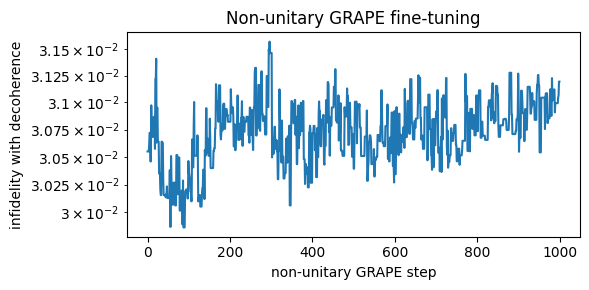

In [ ]:
# ============================================================
# Non-unitary GRAPE fine-tuning
# Rerunning this cell continues from the current decay-optimized pulse.
# ============================================================

n_steps_decay = 1000
learning_rate = 2e-7
decay_param_clip = 2.0

decay_optimizer = optax.adam(learning_rate=learning_rate)

try:
    grape_ctrl_coeffs_decay
    decay_opt_state
    grape_decay_fid_hist
    print("Continuing existing non-unitary GRAPE optimization.")
except NameError:
    grape_ctrl_coeffs_decay = jnp.clip(grape_ctrl_coeffs, -decay_param_clip, decay_param_clip)
    decay_opt_state = decay_optimizer.init(grape_ctrl_coeffs_decay)
    grape_decay_fid_hist = []
    print("Starting non-unitary GRAPE from current unitary-GRAPE pulse.")


@jax.jit
def decay_grape_train_step(ctrl_coeffs, opt_state):
    def loss_fn(c):
        fid = decay_grape_fidelity(c)
        return 1.0 - fid, fid

    (loss_value, fid_value), grads = jax.value_and_grad(loss_fn, has_aux=True)(ctrl_coeffs)

    updates, opt_state = decay_optimizer.update(grads, opt_state)
    ctrl_coeffs = optax.apply_updates(ctrl_coeffs, updates)

    # Same idea as the older notebook: keep coefficients bounded.
    ctrl_coeffs = jnp.clip(ctrl_coeffs, -decay_param_clip, decay_param_clip)

    return ctrl_coeffs, opt_state, loss_value, fid_value


print("Initial/current decay fidelity:", float(decay_grape_fidelity(grape_ctrl_coeffs_decay)))

pbar = tqdm(range(n_steps_decay), desc="non-unitary GRAPE")
for _ in pbar:
    grape_ctrl_coeffs_decay, decay_opt_state, decay_loss_val, decay_fid_val = decay_grape_train_step(
        grape_ctrl_coeffs_decay,
        decay_opt_state,
    )

    grape_decay_fid_hist.append(float(decay_fid_val))
    pbar.set_postfix(fid=f"{float(decay_fid_val):.8f}")

# Make downstream cells use the non-unitary-optimized pulse.
grape_ctrl_coeffs = grape_ctrl_coeffs_decay
grape_ctrl_coeffs_np = np.asarray(grape_ctrl_coeffs, dtype=float)

# Keep your existing export cell compatible if it uses grape_fid_hist[-1].
grape_fid_hist.append(float(grape_decay_fid_hist[-1]))

print("Final non-unitary-GRAPE fidelity:", grape_decay_fid_hist[-1])
print("grape_ctrl_coeffs shape:", grape_ctrl_coeffs_np.shape)

plt.figure(figsize=(6, 3))
plt.semilogy(1.0 - np.asarray(grape_decay_fid_hist))
plt.xlabel("non-unitary GRAPE step")
plt.ylabel("infidelity with decoherence")
plt.title("Non-unitary GRAPE fine-tuning")
plt.tight_layout()
plt.show()

# double check GRAPE pulse with a known working hamiltonian

Loaded optimization bundle from: /home/user/python_experiments/train_feedback_grape/trained_nn15_05_27_corrected_readout_rotation_big/grape_bspline_coeffs/grape_quad_bspline_bundle_fock_2fid_10000_Tns_1408_20260529_07_10.npz


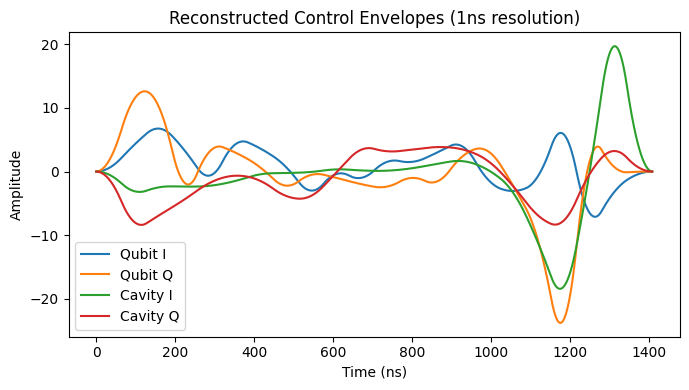

In [ ]:
import os
import glob
import numpy as np
import jax.numpy as jnp
import dynamiqs as dq
import qutip as qt
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
from qutip import wigner
from IPython.display import HTML
from matplotlib import animation
from matplotlib.patches import Circle


data = np.load(bundle_path)
print(f"Loaded optimization bundle from: {bundle_path}")

coeffs = data['coeffs_raw']*20.0
T_ns_hw = int(data['T_ns'])
T_us_hw = float(data['T_us'])

# --- Reconstruct on a fine 1ns grid for Dynamiqs ---
# Dynamiqs PWC requires N edges and N-1 amplitudes (midpoints)
time_intervals_num = T_ns_hw 
t_edges_us = np.linspace(0, T_us_hw, time_intervals_num + 1)
t_mids_us  = (t_edges_us[1:] + t_edges_us[:-1]) / 2
delta_ts = t_edges_us[1:] - t_edges_us[:-1]

# Rebuild the builder using saved metadata
bspline_builder = setup_bspline_builder(
    time_start=0.0, 
    time_end=T_us_hw, 
    n=int(data['n']), 
    k=int(data['k']), 
    skip_left=int(data['skip_left']), 
    skip_right=int(data['skip_right'])
)

bsplns_mids = bspline_builder(t_mids_us)
fields_mids = coeffs @ bsplns_mids  # Shape: (4, time_intervals_num)

eps_qubit_I = fields_mids[0]
eps_qubit_Q = fields_mids[1]
eps_cav_I   = fields_mids[2]
eps_cav_Q   = fields_mids[3]

plt.figure(figsize=(7,4))
plt.plot(t_mids_us * 1e3, eps_qubit_I, label="Qubit I")
plt.plot(t_mids_us * 1e3, eps_qubit_Q, label="Qubit Q")
plt.plot(t_mids_us * 1e3, eps_cav_I, label="Cavity I")
plt.plot(t_mids_us * 1e3, eps_cav_Q, label="Cavity Q")
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude")
plt.title("Reconstructed Control Envelopes (1ns resolution)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
N_cav_dq = 40
N_lev_dq = 3

# Operators
Iq = dq.eye(N_lev_dq)
Ic = dq.eye(N_cav_dq)
a_q = dq.tensor(dq.destroy(N_lev_dq), Ic)
a_c = dq.tensor(Iq, dq.destroy(N_cav_dq))
a_q_dag = dq.dag(a_q)
a_c_dag = dq.dag(a_c)
n_q = a_q_dag @ a_q
n_phot = a_c_dag @ a_c

# Drift Hamiltonian
chi_mhz = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
aham_mhz = 2 * jnp.pi * cfg["anharmonicity_MHz"]
cavity_self_kerr = 2*jnp.pi*cfg["self_Kerr_kHz"]*1e-3  # cavity self-Kerr MHz

H0 = chi_mhz * n_phot @ n_q + (aham_mhz / 2) * a_q_dag @ a_q_dag @ a_q @ a_q + 0.5 * cavity_self_kerr * (a_c_dag @ a_c_dag @ a_c @ a_c)

# Control Hamiltonians (Matches the I+iQ derivation)
H_ctrl_qub_I = a_q + a_q_dag
H_ctrl_qub_Q = -1j * (a_q_dag - a_q)
H_ctrl_cav_I = 1j * (a_c_dag - a_c)
H_ctrl_cav_Q = (a_c + a_c_dag)

# Dissipation Rates (Units: MHz)
kappa_s = 1 / cfg["storage_T1_us"] 
kappa_t1 = 1 / cfg["qubit_T1_us"] 
kappa_t2 = 1 / cfg["qubit_T2_us"] 
kappa_phi = -kappa_t1 / 2 + kappa_t2

n_th_cav = cfg["storage_thermal_population"]
n_th_qubit = cfg["qubit_thermal_population"]

rate_down_cav = kappa_s * (1 - n_th_cav)
rate_up_cav = kappa_s * n_th_cav
rate_down_qubit = kappa_t1 * (1 - n_th_qubit)
rate_up_qubit = kappa_t1 * n_th_qubit
rate_phase = kappa_phi

# Jump Operators
l_down_cav = jnp.sqrt(rate_down_cav) * a_c
l_up_cav = jnp.sqrt(rate_up_cav) * a_c_dag
l_down_qubit = jnp.sqrt(rate_down_qubit) * a_q
l_up_qubit = jnp.sqrt(rate_up_qubit) * a_q_dag
l_phase = jnp.sqrt(2 * rate_phase) * n_q

jump_ops = [l_down_cav, l_up_cav, l_down_qubit, l_up_qubit, l_phase]

In [ ]:
# Initial and Target States
psi_init_dq = dq.tensor(dq.basis(N_lev_dq, 0), dq.basis(N_cav_dq, 0))
rho0 = dq.todm(psi_init_dq)




psi_target_cav_dq = dq.coherent(N_cav_dq, 2.0)-dq.coherent(N_cav_dq, -2.0)
# psi_target_cav_dq =dq.basis(N_cav_dq,2)
psi_target_cav_dq = psi_target_cav_dq/dq.norm(psi_target_cav_dq)

psi_target_dq = dq.tensor(dq.basis(N_lev_dq, 0),psi_target_cav_dq)
rho_target = dq.todm(psi_target_dq)

# Construct Time-Dependent Hamiltonian
t_edges = jnp.asarray(t_edges_us)
eps_qub_I_jnp = jnp.asarray(eps_qubit_I)
eps_qub_Q_jnp = jnp.asarray(eps_qubit_Q)
eps_cav_I_jnp = jnp.asarray(eps_cav_I)
eps_cav_Q_jnp = jnp.asarray(eps_cav_Q)

H_qub_I_t = dq.pwc(t_edges, eps_qub_I_jnp, H_ctrl_qub_I)
H_qub_Q_t = dq.pwc(t_edges, eps_qub_Q_jnp, H_ctrl_qub_Q)
H_cav_I_t = dq.pwc(t_edges, eps_cav_I_jnp, H_ctrl_cav_I)
H_cav_Q_t = dq.pwc(t_edges, eps_cav_Q_jnp, H_ctrl_cav_Q)

H_t = H0 + H_qub_I_t + H_qub_Q_t + H_cav_I_t + H_cav_Q_t

# Integration settings
tsave = t_edges # Save at every 1 ns edge
method = dq.method.Tsit5(rtol=1e-8, atol=1e-10, max_steps=1_000_000)
opts   = dq.Options(save_states=True, progress_meter=True)

# Solve
result_dq = dq.mesolve(
    H=H_t,
    jump_ops=jump_ops,
    rho0=rho0,
    tsave=tsave,
    exp_ops=[n_phot, n_q], 
    method=method,
    options=opts,
)

rho_final = result_dq.states[-1]
F_final = float(dq.fidelity(rho_final, rho_target))
print(f"Fidelity (mesolve, with decoherence): {F_final:.8f}")

|██████████| 100.0% ◆ elapsed 7.78s ◆ remaining 0.00ms  


Fidelity (mesolve, with decoherence): 0.96555507


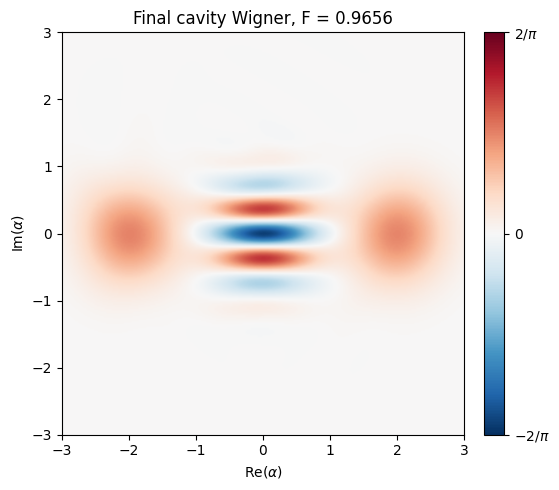

In [ ]:
# Final cavity Wigner using Dynamiqs
rho_cav_final = dq.ptrace(rho_final, keep=1, dims=(N_lev_dq, N_cav_dq))

fig, ax = plt.subplots(figsize=(6, 5))
dq.plot.wigner(
    rho_cav_final,
    ax=ax,
    xmax=3.0,
    npixels=301,
    cmap="RdBu_r",
    colorbar=True,
)
ax.set_title(f"Final cavity Wigner, F = {F_final:.4f}")
plt.tight_layout()
plt.show()